# YOLOv5






## Импорт библиотек

In [1]:
import sys

!{sys.executable} -m pip uninstall -y albumentations albucore stringzilla simsimd
!{sys.executable} -m pip install --no-cache-dir "albumentations==1.3.1"

Found existing installation: albumentations 1.3.1
Uninstalling albumentations-1.3.1:
  Successfully uninstalled albumentations-1.3.1



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Для загрузки и анализа данных
import os
import tarfile
import urllib.request
import glob
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET
from tqdm import tqdm
from sklearn import preprocessing
from time import time

# Для работы с изображениями и построения модели
import torch
import torchvision
from torchvision import transforms
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader, Dataset
from PIL import Image, ImageDraw
from albumentations import (HorizontalFlip, ShiftScaleRotate, VerticalFlip, Normalize,Flip,
                            Compose, GaussNoise)
import cv2
import shutil
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from IPython.display import display

## Загрузка данных

In [16]:
# Загрузка датасета
if not os.path.exists("VOCdevkit"):
    if not os.path.exists("VOC.tar"):
        urllib.request.urlretrieve(
            "http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar", "VOC.tar"
        )
    with tarfile.open("VOC.tar") as tar:
        tar.extractall()

In [3]:
def xml_to_csv(path = 'VOCdevkit/VOC2012/Annotations/'):
    xml_list = []
    for xml_file in tqdm(glob.glob(path + '/2010*.xml')):
        tree = ET.parse(xml_file)
        root = tree.getroot()
        for obj in root.findall('object'):
            bbx = obj.find('bndbox')
            xmin = int(bbx.find('xmin').text)
            ymin = int(bbx.find('ymin').text)
            xmax = int(bbx.find('xmax').text)
            ymax = int(bbx.find('ymax').text)
            label = obj.find('name').text

            value = (root.find('filename').text,
                     int(root.find('size')[0].text),
                     int(root.find('size')[1].text),
                     int(root.find('size')[2].text),
                     label,
                     xmin,
                     ymin,
                     xmax,
                     ymax
                     )
            xml_list.append(value)
    column_name = ['filename', 'channels', 'width', 'height',
                   'class', 'xmin', 'ymin', 'xmax', 'ymax']
    xml_df = pd.DataFrame(xml_list, columns=column_name)
    return xml_df

In [4]:
xml_df = xml_to_csv()
xml_df.to_csv('VOC_2010.csv', index=None)
print('Конвертация прошла успешно.')

100%|██████████| 3503/3503 [00:45<00:00, 76.45it/s]


Конвертация прошла успешно.


In [5]:
xml_df = xml_df[:100]

In [6]:
xml_df.head()

,filename,channels,width,height,class,xmin,ymin,xmax,ymax
0,2010_000001.jpg,3,333,500,cat,123,13,341,313
1,2010_000001.jpg,3,333,500,chair,294,13,410,236
2,2010_000001.jpg,3,333,500,chair,418,198,500,290
3,2010_000001.jpg,3,333,500,chair,362,1,498,80
4,2010_000001.jpg,3,333,500,diningtable,1,219,500,333


In [7]:
print(f'Общее количество объектов {xml_df.shape[0]}')
print(f'Количество изображений в датафрэйме {len(np.unique(xml_df["filename"]))}')

Общее количество объектов 100
Количество изображений в датафрэйме 48


## Обработка данных 

Закодируем классы обьектов.

In [8]:
le = preprocessing.LabelEncoder()
xml_df['class'] = le.fit_transform(xml_df['class'])

In [9]:
xml_df.head()

,filename,channels,width,height,class,xmin,ymin,xmax,ymax
0,2010_000001.jpg,3,333,500,7,123,13,341,313
1,2010_000001.jpg,3,333,500,8,294,13,410,236
2,2010_000001.jpg,3,333,500,8,418,198,500,290
3,2010_000001.jpg,3,333,500,8,362,1,498,80
4,2010_000001.jpg,3,333,500,10,1,219,500,333


Сохраним кодировку классов в переменной mapping.

In [10]:
mapping = dict(zip(le.classes_, range(len(le.classes_))))

In [11]:
mapping

{'aeroplane': 0,
 'bicycle': 1,
 'bird': 2,
 'boat': 3,
 'bottle': 4,
 'bus': 5,
 'car': 6,
 'cat': 7,
 'chair': 8,
 'cow': 9,
 'diningtable': 10,
 'dog': 11,
 'horse': 12,
 'motorbike': 13,
 'person': 14,
 'pottedplant': 15,
 'sheep': 16,
 'sofa': 17,
 'train': 18,
 'tvmonitor': 19}

Теперь нам нужно привести наши данные к формату **YOLOv5**.

Аннотация каждого объекта должна сожержать следующую информацию:

`Class X Y Width Height`

![picture](https://drive.google.com/uc?export=view&id=1yUJt5XTvYo4MbWxKAxhPdCk-yCnQ1AEz)


Для этого воспользуемся вспомогательной функцией `convert_to_yolov5`.



In [12]:
def convert_to_yolov5(df, unique_img_names):

    df_array = np.array(df)

    # Для каждого объкта
    for i in range(len(df)):
        print_buffer = []

        point =  df_array[i]
        img_name = point[0]

        # Для каждого уникального изображения
        for unique_img_name in unique_img_names:
           if img_name == unique_img_name:
              class_id = point[4]
      
              # Преобразуем координаты bbox 
              X = (point[5] + point[7]) / 2 
              Y = (point[6] + point[8]) / 2 
              Width    = (point[7] - point[5])
              Height   = (point[8] - point[6])
              
              # Нормализуем координаты
              image_c, image_w, image_h = point[1], point[2], point[3] 
              X /= image_w 
              Y /= image_h 
              Width    /= image_w 
              Height   /= image_h 
              
              # Запишем информацию о bbox в файл
              print_buffer.append("{} {:.3f} {:.3f} {:.3f} {:.3f}".format(class_id, X, Y, Width, Height))
              
        # Дадим имя файлам, которые хотим сохранить
        save_file_name = os.path.join("VOCdevkit/VOC2012/JPEGImages/", img_name.replace("jpg", "txt"))
        
        # Сохраним аннотации на диск
        print("\n".join(print_buffer), file= open(save_file_name, "w"))

In [13]:
# Для начала выделим список уникальных имен изображений
unique_img_names = xml_df['filename'].unique()
print(len(unique_img_names))

48


In [14]:
# Получим аннотации в новом формате
convert_to_yolov5(xml_df, unique_img_names)

Давайте протестируем трансформированные аннотиции с помощью визуализации.

In [15]:
class_id_to_name_mapping = dict(zip(mapping.values(), mapping.keys()))

In [16]:
def plot_bounding_box(image, annotation_list):
    annotations = np.array(annotation_list)
    w, h = image.size

    plotted_image = ImageDraw.Draw(image)

    transformed_annotations = np.copy(annotations)
    print(transformed_annotations)
    transformed_annotations[:,[1,3]] = annotations[:,[1,3]] * w
    transformed_annotations[:,[2,4]] = annotations[:,[2,4]] * h 
    
    transformed_annotations[:,1] = transformed_annotations[:,1] - (transformed_annotations[:,3] / 2)
    transformed_annotations[:,2] = transformed_annotations[:,2] - (transformed_annotations[:,4] / 2)
    transformed_annotations[:,3] = transformed_annotations[:,1] + transformed_annotations[:,3]
    transformed_annotations[:,4] = transformed_annotations[:,2] + transformed_annotations[:,4]
    
    for ann in transformed_annotations:
        obj_cls, x0, y0, x1, y1 = ann
        plotted_image.rectangle(((x0,y0), (x1,y1)))

        plotted_image.text((x0, y0 - 10), class_id_to_name_mapping[(int(obj_cls))], fill="#000")
    
    
    plt.imshow(np.array(image))
    plt.show()

In [17]:
# Выберем рандомную аннотацию 
from pathlib import Path
import random

labels_dir = Path("VOCdevkit") / "VOC2012" / "JPEGImages"

annotation_files = list(labels_dir.glob("*.txt"))

if not annotation_files:
    raise FileNotFoundError(
        f"В папке {labels_dir.resolve()} не найдено файлов разметки .txt. "
        "Сначала выполните convert_to_yolov5(xml_df, unique_img_names)."
    )

annotation_file = random.choice(annotation_files)

print("Случайный файл разметки:", annotation_file)

Случайный файл разметки: VOCdevkit\VOC2012\JPEGImages\2010_000069.txt


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import ImageDraw

def plot_bounding_box_image(image, annotation_list):
    """
    Рисует боксы из YOLO-разметки:
    class_id x_center y_center width height,
    где координаты нормализованы в диапазоне [0, 1].
    """
    image = image.copy()
    draw = ImageDraw.Draw(image)

    width, height = image.size

    for annotation in annotation_list:
        class_id, x_center, y_center, box_width, box_height = annotation

        x_center *= width
        y_center *= height
        box_width *= width
        box_height *= height

        x_min = x_center - box_width / 2
        y_min = y_center - box_height / 2
        x_max = x_center + box_width / 2
        y_max = y_center + box_height / 2

        class_id = int(class_id)
        class_name = class_id_to_name_mapping.get(
            class_id,
            f"class_{class_id}"
        )

        draw.rectangle(
            [x_min, y_min, x_max, y_max],
            outline="red",
            width=3
        )

        draw.text(
            (x_min, max(0, y_min - 15)),
            class_name,
            fill="red"
        )

    plt.figure(figsize=(10, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Исходная YOLO-разметка")
    plt.show()

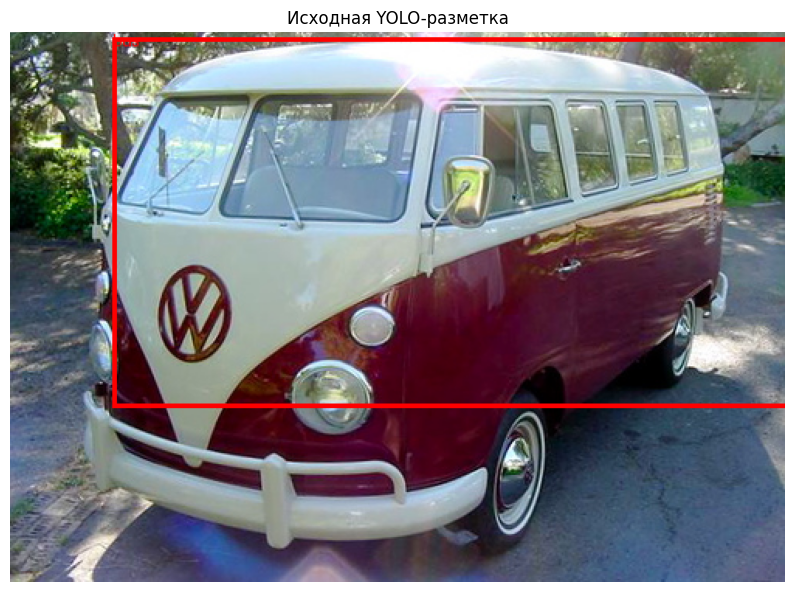

In [19]:
with open(annotation_file, "r", encoding="utf-8") as file:
    annotation_list = [
        [float(value) for value in line.split()]
        for line in file
        if line.strip()
    ]

image_file = annotation_file.with_suffix(".jpg")

if not image_file.exists():
    raise FileNotFoundError(f"Не найдено изображение: {image_file}")

image = Image.open(image_file).convert("RGB")

plot_bounding_box_image(image, annotation_list)

Обученная модель находится в классе hub библиотеки `torch`.

Давайте посмотрим на предсказания модели для нашей рандомной картинки.

In [20]:
from pathlib import Path
import random

val_dir = Path("yolo_dataset") / "images" / "val"

print("Папка validation:")
print(val_dir.resolve())
print("Существует:", val_dir.exists())

image_files = list(val_dir.glob("*.jpg"))

print("Найдено изображений:", len(image_files))

if not image_files:
    raise FileNotFoundError(
        f"В папке нет JPG-изображений: {val_dir.resolve()}"
    )

img = random.choice(image_files)

print("Выбрано изображение:")
print(img.resolve())

Папка validation:
C:\Users\aleks\Documents\IDE\CV-5. Распознавание объектов. Часть II\yolo_dataset\images\val
Существует: True
Найдено изображений: 10
Выбрано изображение:
C:\Users\aleks\Documents\IDE\CV-5. Распознавание объектов. Часть II\yolo_dataset\images\val\2010_000079.jpg


YOLOv5  2026-9-13 Python-3.11.0 torch-2.14.0+cpu CPU

Fusing layers... 
YOLOv5s summary: 124 layers, 7,225,885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
image 1/1: 375x500 2 dogs, 1 remote, 3 books
Speed: 36.1ms pre-process, 132.2ms inference, 18.5ms NMS per image at shape (1, 3, 256, 320)


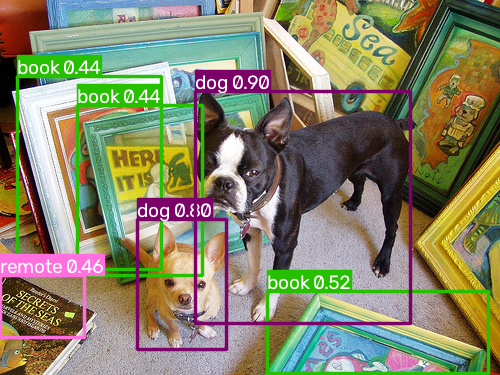

In [21]:
import torch

model = torch.hub.load(
    "./yolov5",
    "custom",
    path="./yolov5/yolov5s.pt",
    source="local",
    device="cpu"
)

results = model(str(img), size=320)

results.print()
results.show()

## ЗАДАНИЕ

Обучите модель **yolov5**,  используя готовый `train.py` файл репозитория https://github.com/ultralytics/yolov5.git.

Для данной модели изображения и классы объектов должны находиться в папках images и labels, соответсвенно.

Протестируйте модель на валидациооной выборке и выведите на экран полученные изображения с bbox и классами объектов.

In [41]:
import os
import glob
import shutil
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET

from pathlib import Path
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Пути
project_dir = Path.cwd()
voc_dir = project_dir / "VOCdevkit" / "VOC2012"
annotations_dir = voc_dir / "Annotations"
images_source_dir = voc_dir / "JPEGImages"

# 1. Читаем XML-аннотации
def xml_to_dataframe(annotations_dir):
    rows = []

    xml_files = sorted(annotations_dir.glob("2010*.xml"))

    for xml_file in tqdm(xml_files):
        root = ET.parse(xml_file).getroot()

        filename = root.find("filename").text
        image_width = int(root.find("size/width").text)
        image_height = int(root.find("size/height").text)
        channels = int(root.find("size/depth").text)

        for obj in root.findall("object"):
            label = obj.find("name").text
            box = obj.find("bndbox")

            xmin = int(box.find("xmin").text)
            ymin = int(box.find("ymin").text)
            xmax = int(box.find("xmax").text)
            ymax = int(box.find("ymax").text)

            rows.append({
                "filename": filename,
                "channels": channels,
                "width": image_width,
                "height": image_height,
                "class": label,
                "xmin": xmin,
                "ymin": ymin,
                "xmax": xmax,
                "ymax": ymax,
            })

    return pd.DataFrame(rows)

xml_df = xml_to_dataframe(annotations_dir)

# Для быстрого учебного запуска используем первые 100 объектов,
# как в основном ноутбуке.
xml_df = xml_df.iloc[:100].copy()

print("Строк:", len(xml_df))
print("Уникальных изображений:", xml_df["filename"].nunique())

# 2. Кодируем классы
label_encoder = LabelEncoder()
xml_df["class"] = label_encoder.fit_transform(xml_df["class"])

class_names = list(label_encoder.classes_)

print("Классы:", class_names)

# 3. Пересоздаём labels рядом с изображениями
def convert_xml_df_to_yolo(df, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    for filename, group in df.groupby("filename"):
        image_width = float(group.iloc[0]["width"])
        image_height = float(group.iloc[0]["height"])

        lines = []

        for _, row in group.iterrows():
            xmin = float(row["xmin"])
            ymin = float(row["ymin"])
            xmax = float(row["xmax"])
            ymax = float(row["ymax"])

            # Правильная нормализация:
            # X делится на width, Y делится на height
            x_center = ((xmin + xmax) / 2.0) / image_width
            y_center = ((ymin + ymax) / 2.0) / image_height
            box_width = (xmax - xmin) / image_width
            box_height = (ymax - ymin) / image_height

            coords = [x_center, y_center, box_width, box_height]

            if not all(0 <= value <= 1 for value in coords):
                raise ValueError(
                    f"Некорректные координаты в {filename}: {coords}"
                )

            lines.append(
                f"{int(row['class'])} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{box_width:.6f} "
                f"{box_height:.6f}"
            )

        label_path = output_dir / Path(filename).with_suffix(".txt")
        label_path.write_text("\n".join(lines) + "\n", encoding="utf-8")

convert_xml_df_to_yolo(
    xml_df,
    images_source_dir
)

print("YOLO-разметка пересоздана.")

# 4. Проверяем все labels
def validate_yolo_labels(labels_dir):
    errors = []

    for label_path in Path(labels_dir).glob("*.txt"):
        for line_number, line in enumerate(
            label_path.read_text(encoding="utf-8").splitlines(),
            start=1
        ):
            values = line.split()

            if len(values) != 5:
                errors.append(
                    f"{label_path.name}:{line_number}: {line}"
                )
                continue

            try:
                int(values[0])
                coords = [float(value) for value in values[1:]]
            except ValueError:
                errors.append(
                    f"{label_path.name}:{line_number}: non-numeric"
                )
                continue

            if not all(0 <= value <= 1 for value in coords):
                errors.append(
                    f"{label_path.name}:{line_number}: {coords}"
                )

    return errors

label_errors = validate_yolo_labels(images_source_dir)

print("Ошибок в labels:", len(label_errors))

if label_errors:
    for error in label_errors[:10]:
        print(error)
    raise RuntimeError("Разметка всё ещё содержит ошибки.")

# 5. Делим по уникальным изображениям
unique_images = xml_df["filename"].unique()

train_images, val_images = train_test_split(
    unique_images,
    test_size=0.2,
    random_state=42
)

# 6. Очищаем старый yolo_dataset
dataset_dir = project_dir / "yolo_dataset"

if dataset_dir.exists():
    shutil.rmtree(dataset_dir)

for split in ["train", "val"]:
    (dataset_dir / "images" / split).mkdir(parents=True, exist_ok=True)
    (dataset_dir / "labels" / split).mkdir(parents=True, exist_ok=True)

# 7. Копируем images и labels
for split, image_names in [
    ("train", train_images),
    ("val", val_images)
]:
    for filename in image_names:
        image_source = images_source_dir / filename
        label_source = images_source_dir / Path(filename).with_suffix(".txt")

        image_target = dataset_dir / "images" / split / filename
        label_target = (
            dataset_dir
            / "labels"
            / split
            / Path(filename).with_suffix(".txt")
        )

        shutil.copy2(image_source, image_target)
        shutil.copy2(label_source, label_target)

print("Train:", len(train_images))
print("Validation:", len(val_images))

# 8. Создаём data.yaml
yaml_path = dataset_dir / "data.yaml"

yaml_text = (
    f"path: {dataset_dir.resolve().as_posix()}\n"
    "train: images/train\n"
    "val: images/val\n"
    f"nc: {len(class_names)}\n"
    f"names: {class_names}\n"
)

yaml_path.write_text(yaml_text, encoding="utf-8")

print("\nСоздан data.yaml:")
print(yaml_text)

100%|██████████| 3503/3503 [00:05<00:00, 691.31it/s] 


Строк: 100
Уникальных изображений: 48
Классы: ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']
YOLO-разметка пересоздана.
Ошибок в labels: 0
Train: 38
Validation: 10

Создан data.yaml:
path: C:/Users/aleks/Documents/IDE/CV-5. Распознавание объектов. Часть II/yolo_dataset
train: images/train
val: images/val
nc: 20
names: ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']



In [42]:
from pathlib import Path

yolov5_dir = Path("yolov5")

print("YOLOv5 существует:", yolov5_dir.exists())
print("train.py существует:", (yolov5_dir / "train.py").exists())
print("data.yaml существует:", (Path("yolo_dataset") / "data.yaml").exists())

YOLOv5 существует: True
train.py существует: True
data.yaml существует: True


In [44]:
from pathlib import Path

dataset_dir = Path.cwd() / "yolo_dataset"
yaml_path = dataset_dir / "data.yaml"

yaml_text = """path: .
train: images/train
val: images/val
nc: 20
names: ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']
"""

yaml_path.write_text(yaml_text, encoding="utf-8")

print(yaml_path.resolve())
print(yaml_path.read_text(encoding="utf-8"))

C:\Users\aleks\Documents\IDE\CV-5. Распознавание объектов. Часть II\yolo_dataset\data.yaml
path: .
train: images/train
val: images/val
nc: 20
names: ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']



In [45]:
print("data.yaml:", yaml_path.exists())
print("train:", (dataset_dir / "images" / "train").exists())
print("val:", (dataset_dir / "images" / "val").exists())

print("train images:", len(list((dataset_dir / "images" / "train").glob("*.jpg"))))
print("train labels:", len(list((dataset_dir / "labels" / "train").glob("*.txt"))))
print("val images:", len(list((dataset_dir / "images" / "val").glob("*.jpg"))))
print("val labels:", len(list((dataset_dir / "labels" / "val").glob("*.txt"))))

data.yaml: True
train: True
val: True
train images: 38
train labels: 38
val images: 10
val labels: 10


In [46]:
import subprocess
import sys
from pathlib import Path

project_dir = Path.cwd()
yolov5_dir = project_dir / "yolov5"
data_yaml = project_dir / "yolo_dataset" / "data.yaml"

command = [
    sys.executable,
    "train.py",
    "--img", "640",
    "--batch-size", "8",
    "--epochs", "1",
    "--data", str(data_yaml.resolve()),
    "--weights", "yolov5s.pt",
    "--project", "runs/train",
    "--name", "voc_correct_test",
    "--exist-ok",
    "--workers", "0",
    "--cache", "disk",
    "--device", "cpu"
]

print("Рабочая папка:", yolov5_dir.resolve())
print("Команда:", " ".join(command))

subprocess.run(
    command,
    cwd=str(yolov5_dir.resolve()),
    check=True
)

Рабочая папка: C:\Users\aleks\Documents\IDE\CV-5. Распознавание объектов. Часть II\yolov5
Команда: c:\Users\aleks\AppData\Local\Programs\Python\Python311\python.exe train.py --img 640 --batch-size 8 --epochs 1 --data C:\Users\aleks\Documents\IDE\CV-5. Распознавание объектов. Часть II\yolo_dataset\data.yaml --weights yolov5s.pt --project runs/train --name voc_correct_test --exist-ok --workers 0 --cache disk --device cpu


CalledProcessError: Command '['c:\\Users\\aleks\\AppData\\Local\\Programs\\Python\\Python311\\python.exe', 'train.py', '--img', '640', '--batch-size', '8', '--epochs', '1', '--data', 'C:\\Users\\aleks\\Documents\\IDE\\CV-5. Распознавание объектов. Часть II\\yolo_dataset\\data.yaml', '--weights', 'yolov5s.pt', '--project', 'runs/train', '--name', 'voc_correct_test', '--exist-ok', '--workers', '0', '--cache', 'disk', '--device', 'cpu']' returned non-zero exit status 1.

Сделайте сравнение текущей модели с Faster RCNN по скорости и качетсву.